<a href="https://colab.research.google.com/github/dhanwariagarvit21/cont-s-stylized-facts/blob/main/gain_loss_asymmetry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [53]:
one_minute_nifty = yf.download('^NSEI',period='1mo',interval='5m')
one_year_nifty = yf.download('^NSEI',start = '2021-01-01',end = '2026-01-01')
one_minute_Reliance = yf.download('Reliance.NS',period='1mo',interval='5m')
one_year_Reliance = yf.download('Reliance.NS',start = '2021-01-01',end = '2026-01-01')

/tmp/ipykernel_1057/1161508799.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  one_minute_nifty = yf.download('^NSEI',period='1mo',interval='5m')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1057/1161508799.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  one_year_nifty = yf.download('^NSEI',start = '2021-01-01',end = '2026-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1057/1161508799.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  one_minute_Reliance = yf.download('Reliance.NS',period='1mo',interval='5m')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1057/1161508799.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  one_year_Reliance = yf.download('Reliance.NS',start = '2021-01-01',end = '2026-01-01')
[****************

In [54]:
def hill_plot(x, k_min=20, k_max=None, step=10):
    if isinstance(x, pd.DataFrame) and len(x.columns) == 1:
        x = x.iloc[:, 0]
    x_clean = np.abs(x.dropna())
    x_clean = x_clean[x_clean != 0]
    n = len(x_clean)
    if k_max is None:
        k_max = min(int(n * 0.2), 300)
    ks = range(k_min, k_max, step)
    alphas = [hill_estimator(x_clean, k) for k in ks]

    plt.plot(list(ks), alphas)
    plt.xlabel("k"); plt.ylabel(r"$\hat{\alpha}_{Hill}$")
    plt.axhline(np.nanmedian(alphas), ls='--', color='gray', alpha=0.6)
    plt.title(f"Hill plot (n={n})")
    return ks

In [55]:
raw_returns_nifty = np.log(one_year_nifty['Close'] / one_year_nifty['Close'].shift(1))
raw_returns_Reliance = np.log(one_year_Reliance['Close'] / one_year_Reliance['Close'].shift(1))
log_returns_nifty_one_minute = np.log(one_minute_nifty['Close'] / one_minute_nifty['Close'].shift(1))
log_returns_Reliance_one_minute = np.log(one_minute_Reliance['Close'] / one_minute_Reliance['Close'].shift(1))

In [56]:
def pos_neg_sep(df):
  positive_returns = df[df > 0]
  negative_returns = df[df < 0]
  return positive_returns, negative_returns


In [57]:
def calculate_hill_estimator(df):
  positive_returns, negative_returns = pos_neg_sep(df)
  hill_estimator_positive = hill_estimator(positive_returns, 10)
  hill_estimator_negative = hill_estimator(negative_returns, 10)
  if np.isnan(hill_estimator_positive):
    hill_estimator_positive = 0
  if np.isnan(hill_estimator_negative):
    hill_estimator_negative = 0
  return hill_estimator_positive, hill_estimator_negative

In [58]:
print(calculate_hill_estimator(log_returns_nifty_one_minute))
print(calculate_hill_estimator(log_returns_Reliance_one_minute))
print(calculate_hill_estimator(raw_returns_nifty))
print(calculate_hill_estimator(raw_returns_Reliance))

(np.float64(1.0716933326123725), np.float64(1.8931146930110976))
(np.float64(2.854867527890938), np.float64(2.9571073175008498))
(np.float64(3.992266352832121), np.float64(3.879480711917935))
(np.float64(4.204598812969678), np.float64(3.405468516975089))


In [59]:
datasets = {
    'Nifty 1-min': log_returns_nifty_one_minute,
    'Reliance 1-min': log_returns_Reliance_one_minute,
    'Nifty 1-year': raw_returns_nifty,
    'Reliance 1-year': raw_returns_Reliance
}

hill_results = {}
for name, data in datasets.items():
    pos_he, neg_he = calculate_hill_estimator(data)
    hill_results[name] = {'Positive Hill Estimator': pos_he, 'Negative Hill Estimator': neg_he}

hill_df = pd.DataFrame(hill_results).T
display(hill_df)

,Positive Hill Estimator,Negative Hill Estimator
Nifty 1-min,1.071693,1.893115
Reliance 1-min,2.854868,2.957107
Nifty 1-year,3.992266,3.879481
Reliance 1-year,4.204599,3.405469


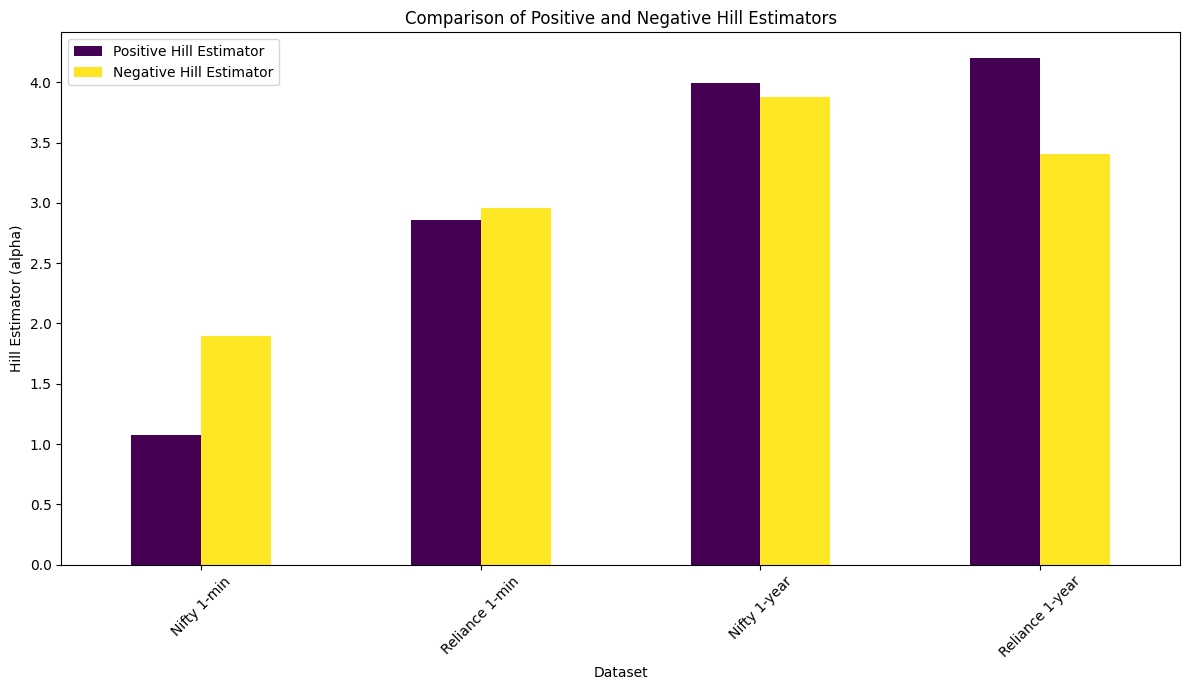

In [60]:
fig, ax = plt.subplots(figsize=(12, 7))
hill_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Comparison of Positive and Negative Hill Estimators')
ax.set_ylabel('Hill Estimator (alpha)')
ax.set_xlabel('Dataset')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()